# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Mochammad Ghani Al-Zyad
- Email: 2207011@itg.ac.id
- Id Dicoding: ghanialzyad

## Persiapan

### Menyiapkan library yang dibutuhkan

In [ ]:
# 1. Library untuk manipulasi dan analisis data
import pandas as pd
import numpy as np

# 2. Library untuk visualisasi data (Exploratory Data Analysis)
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Library untuk Machine Learning (mencari faktor yang mempengaruhi attrition)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# 4. Library untuk pembuatan Business Dashboard
# (Streamlit sangat disarankan karena mudah digunakan dan interaktif)
!pip install streamlit
import streamlit as st

# Mengatur tampilan visualisasi default
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore') # Mengabaikan pesan peringatan yang tidak perlu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 90.7 MB/s eta 0:00:00


### Menyiapkan data yang akan diguankan

## Data Understanding

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
# 1. Memuat dataset dari file CSV
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/employee_data.csv')

# 2. Menampilkan 5 baris pertama untuk melihat gambaran awal datanya
print("--- 5 Baris Pertama Data ---")
display(df.head())

# 3. Melihat informasi dataset (jumlah baris, kolom, dan tipe data)
print("\n--- Informasi Dataset ---")
df.info()

# 4. Mengecek apakah ada missing value (data yang kosong/hilang)
print("\n--- Jumlah Missing Value per Kolom ---")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0]) # Hanya menampilkan kolom yang ada data kosongnya

# 5. Melihat ringkasan statistik dari kolom berupa angka (numerik)
print("\n--- Ringkasan Statistik Data ---")
display(df.describe())

# 1. Menghapus baris yang memiliki missing value pada kolom 'Attrition'
df_clean = df.dropna(subset=['Attrition']).copy()

# 2. Menghapus kolom yang tidak memberikan informasi/variasi
kolom_tidak_perlu = ['EmployeeId', 'EmployeeCount', 'StandardHours', 'Over18']
df_clean = df_clean.drop(columns=kolom_tidak_perlu, errors='ignore')

# 3. Mengubah tipe data 'Attrition' dari float (1.0 / 0.0) menjadi integer (1 / 0)
df_clean['Attrition'] = df_clean['Attrition'].astype(int)

# 4. Membuat kolom baru 'Attrition_Label' (Yes/No) khusus untuk mempercantik visualisasi Dashboard nantinya
df_clean['Attrition_Label'] = df_clean['Attrition'].map({1: 'Yes', 0: 'No'})

# 5. Melihat hasil pembersihan
print("--- Ukuran Data Setelah Dibersihkan ---")
print(f"Jumlah Baris: {df_clean.shape[0]}")
print(f"Jumlah Kolom: {df_clean.shape[1]}")

print("\n--- Sisa Missing Value ---")
print(f"Total missing value di seluruh data: {df_clean.isnull().sum().sum()}")

# 6. Menyimpan data yang sudah bersih untuk digunakan pada Dashboard nanti
df_clean.to_csv('cleaned_employee_data.csv', index=False)
print("\nData yang sudah bersih berhasil disimpan sebagai 'cleaned_employee_data.csv'")

--- 5 Baris Pertama Data ---


,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2



--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-n

,EmployeeId,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1058.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,735.500000,36.923810,0.169187,802.485714,9.192517,2.912925,1.0,2.721769,65.891156,2.729932,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,424.496761,9.135373,0.375094,403.509100,8.106864,1.024165,0.0,1.093082,20.329428,0.711561,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,1.000000,18.000000,0.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,368.250000,30.000000,0.000000,465.000000,2.000000,2.000000,1.0,2.000000,48.000000,2.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,735.500000,36.000000,0.000000,802.000000,7.000000,3.000000,1.0,3.000000,66.000000,3.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1102.750000,43.000000,0.000000,1157.000000,14.000000,4.000000,1.0,4.000000,83.750000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,1470.000000,60.000000,1.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


--- Ukuran Data Setelah Dibersihkan ---
Jumlah Baris: 1058
Jumlah Kolom: 32

--- Sisa Missing Value ---
Total missing value di seluruh data: 0

Data yang sudah bersih berhasil disimpan sebagai 'cleaned_employee_data.csv'


## Data Preparation / Preprocessing

In [9]:
# Pastikan kita menggunakan dataframe yang sudah dibersihkan sebelumnya
# Jika Anda menjalankan ini di sesi baru, gunakan: df_clean = pd.read_csv('cleaned_employee_data.csv')

# 1. Memisahkan fitur / variabel penentu (X) dan target utama (y)
# Kita membuang kolom target 'Attrition' dan 'Attrition_Label' dari X
X = df_clean.drop(columns=['Attrition', 'Attrition_Label'])
y = df_clean['Attrition']

# 2. Encoding Kategorikal (Mengubah data teks menjadi angka / kolom dummy)
# Fungsi get_dummies akan otomatis mengubah kolom teks menjadi nilai 0 dan 1
X_encoded = pd.get_dummies(X, drop_first=True)

# 3. Membagi Data menjadi Data Latih (Training) dan Data Uji (Testing)
# Kita gunakan 80% untuk melatih model, dan 20% untuk mengujinya
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("--- Tahap Data Preparation Selesai! ---")
print(f"Jumlah fitur/kolom setelah di-encode: {X_encoded.shape[1]} kolom")
print(f"Jumlah data untuk dilatih (Training): {X_train.shape[0]} baris")
print(f"Jumlah data untuk diuji (Testing): {X_test.shape[0]} baris")

--- Tahap Data Preparation Selesai! ---
Jumlah fitur/kolom setelah di-encode: 44 kolom
Jumlah data untuk dilatih (Training): 846 baris
Jumlah data untuk diuji (Testing): 212 baris


## Modeling

--- Laporan Evaluasi Model ---
              precision    recall  f1-score   support

           0       0.85      0.99      0.91       176
           1       0.80      0.11      0.20        36

    accuracy                           0.84       212
   macro avg       0.82      0.55      0.55       212
weighted avg       0.84      0.84      0.79       212



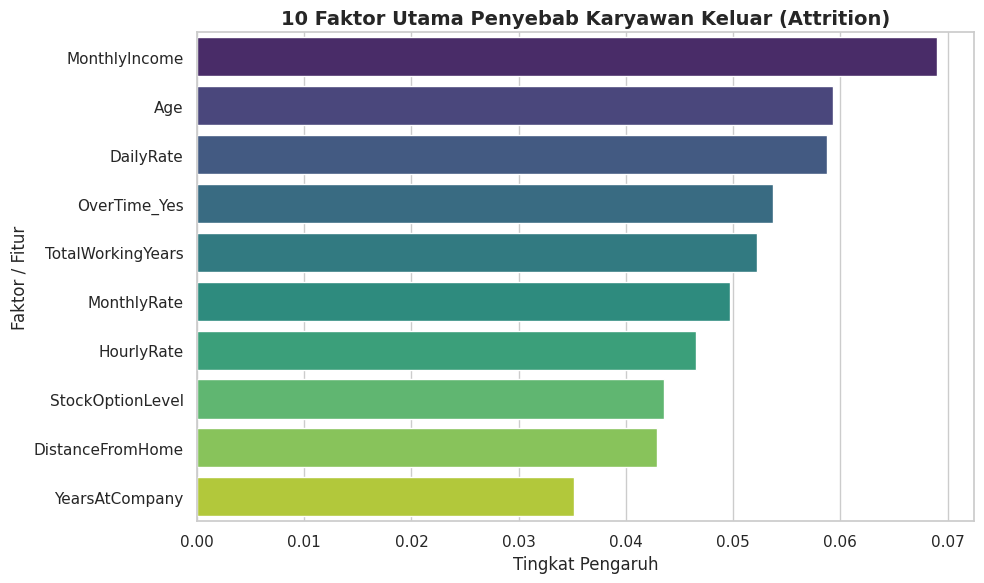

In [10]:
# 1. Inisialisasi Model Random Forest
# n_estimators=100 berarti kita membuat 100 'pohon keputusan' agar hasilnya akurat
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# 2. MELATIH MODEL (Inilah inti dari tahap Modeling)
rf_model.fit(X_train, y_train)

# 3. Menguji seberapa pintar model kita pada data uji (Testing)
y_pred = rf_model.predict(X_test)
print("--- Laporan Evaluasi Model ---")
print(classification_report(y_test, y_pred))

# 4. MENGIDENTIFIKASI FAKTOR UTAMA ATTRITION (Sesuai request Manajer HR)
# Mengambil nilai pentingnya setiap kolom/faktor
feature_importances = rf_model.feature_importances_

# Membuat DataFrame untuk mengurutkan faktor dari yang paling berpengaruh
df_importance = pd.DataFrame({
    'Faktor': X_encoded.columns,
    'Tingkat_Pengaruh': feature_importances
}).sort_values(by='Tingkat_Pengaruh', ascending=False)

# 5. Menampilkan 10 Faktor Teratas dengan Grafik (Visualisasi)
plt.figure(figsize=(10, 6))
sns.barplot(x='Tingkat_Pengaruh', y='Faktor', data=df_importance.head(10), palette='viridis')
plt.title('10 Faktor Utama Penyebab Karyawan Keluar (Attrition)', fontsize=14, fontweight='bold')
plt.xlabel('Tingkat Pengaruh')
plt.ylabel('Faktor / Fitur')
plt.tight_layout()
plt.show()

# 6. Menyimpan 10 faktor teratas ini jika ingin dipanggil di Dashboard nanti
df_importance.head(10).to_csv('top_attrition_factors.csv', index=False)

## Evaluation

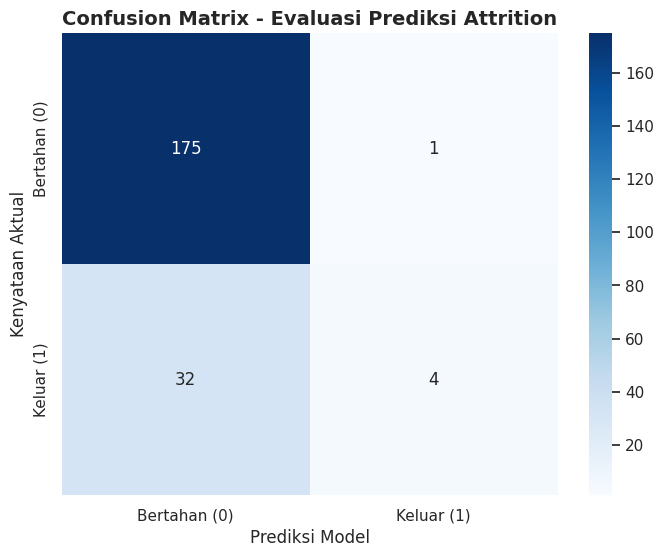


--- Laporan Evaluasi Detail ---
              precision    recall  f1-score   support

Bertahan (0)       0.85      0.99      0.91       176
  Keluar (1)       0.80      0.11      0.20        36

    accuracy                           0.84       212
   macro avg       0.82      0.55      0.55       212
weighted avg       0.84      0.84      0.79       212



In [11]:
from sklearn.metrics import confusion_matrix

# 1. Menghitung Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 2. Membuat Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bertahan (0)', 'Keluar (1)'],
            yticklabels=['Bertahan (0)', 'Keluar (1)'])

plt.title('Confusion Matrix - Evaluasi Prediksi Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Prediksi Model')
plt.ylabel('Kenyataan Aktual')
plt.show()

# 3. Menampilkan Laporan Metrik Lengkap
print("\n--- Laporan Evaluasi Detail ---")
print(classification_report(y_test, y_pred, target_names=['Bertahan (0)', 'Keluar (1)']))